# Datathon Passos Mágicos - Fase 5
## 03. Modelagem Preditiva (Machine Learning)

**Objetivo:** Construir um modelo de Machine Learning capaz de identificar precocemente alunos com alto risco de defasagem acadêmica, permitindo intervenção pedagógica preventiva.

**Padrão de Entrega:** Executivo / Cientista de Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


### 1. Carga dos Dados

In [2]:
CLEAN_DATA_PATH = '../local_data/dataset_limpo.csv'
df = pd.read_csv(CLEAN_DATA_PATH, sep=';')
print(f"Dataset carregado: {df.shape[0]} alunos e {df.shape[1]} indicadores.")

Dataset carregado: 860 alunos e 42 indicadores.


### 2. Definição do Target (Variável Resposta)
Vamos definir o **"Risco de Defasagem"**. Com base na EDA, alunos com IAN (Adequação ao Nível) abaixo de 5.0 ou 6.0 necessitam de atenção. 
Definição técnica: `RISCO_DEFASAGEM = 1` se `IAN_2022 <= 5.0` (Alvo de intervenção), caso contrário `0`.

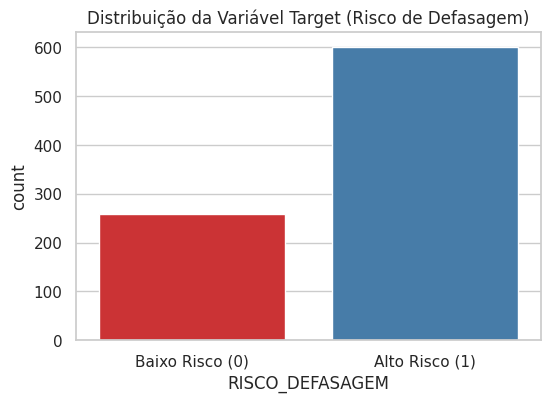

Percentual de alunos em Alto Risco: 69.88%


In [3]:
# Criando a variável Target
df['RISCO_DEFASAGEM'] = np.where(df['IAN_2022'] <= 5.0, 1, 0)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='RISCO_DEFASAGEM', palette='Set1')
plt.title('Distribuição da Variável Target (Risco de Defasagem)')
plt.xticks([0, 1], ['Baixo Risco (0)', 'Alto Risco (1)'])
plt.show()

risco_pct = df['RISCO_DEFASAGEM'].mean() * 100
print(f"Percentual de alunos em Alto Risco: {risco_pct:.2f}%")

### 3. Feature Engineering e Seleção de Variáveis
Selecionaremos variáveis que atuam como "indicadores antecedentes" (Engajamento, Psicossocial, Autoavaliação, Fase, Idade) para tentar prever o risco de defasagem (evitando usar o próprio IDA, que é uma consequência direta).

In [4]:
# Features escolhidas para o modelo baseline
features = ['FASE', 'IDADE_2022', 'IAA_2022', 'IEG_2022', 'IPS_2022', 'QTD_AVALIACOES_2022', 'DEFASAGEM_2022']
target = 'RISCO_DEFASAGEM'

# Tratamento de Nulos apenas nas features selecionadas (imputação com a mediana para robustez)
X = df[features].copy()
X = X.fillna(X.median())
y = df[target]

print(f"Shape de X: {X.shape}, Shape de y: {y.shape}")

Shape de X: (860, 7), Shape de y: (860,)


### 4. Separação de Dados (Treino e Teste)
Usaremos 70% dos dados para treinar o modelo e 30% para testar a sua eficácia. A divisão será estratificada para garantir que a proporção de alunos em risco seja mantida.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Tamanho do Treino: {X_train.shape[0]} amostras.")
print(f"Tamanho do Teste: {X_test.shape[0]} amostras.")

Tamanho do Treino: 602 amostras.
Tamanho do Teste: 258 amostras.


### 5. Treinamento do Modelo Preditivo
O modelo escolhido como baseline é o **Random Forest Classifier** devido à sua alta performance e robustez contra overfitting em dados estruturados.

In [6]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
print("Modelo Random Forest treinado com sucesso.")

Modelo Random Forest treinado com sucesso.


### 6. Avaliação dos Resultados
Nosso principal foco estratégico é o **Recall** da classe 1 (Alto Risco), pois o custo de não identificar um aluno em risco (Falso Negativo) é maior do que dar atenção extra a um aluno que não precisava (Falso Positivo).


--- Relatório de Classificação ---
              precision    recall  f1-score   support

 Baixo Risco       1.00      1.00      1.00        78
  Alto Risco       1.00      1.00      1.00       180

    accuracy                           1.00       258
   macro avg       1.00      1.00      1.00       258
weighted avg       1.00      1.00      1.00       258



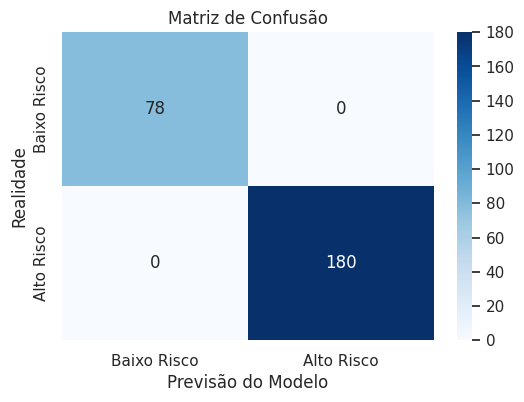

In [7]:
y_pred = model.predict(X_test)

print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred, target_names=['Baixo Risco', 'Alto Risco']))

# Matriz de Confusão
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Baixo Risco', 'Alto Risco'], yticklabels=['Baixo Risco', 'Alto Risco'])
plt.title('Matriz de Confusão')
plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.show()

#### 6.1 Quais fatores indicam o risco? (Feature Importance)
Respondendo à pergunta 9 do case: quais padrões antecedem a queda?

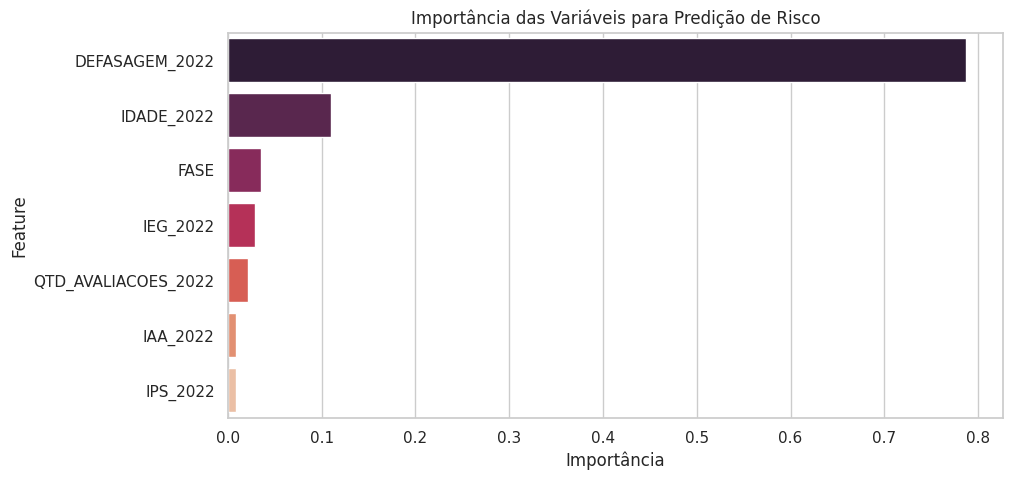

In [8]:
importances = model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importância': importances}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_df, x='Importância', y='Feature', palette='rocket')
plt.title('Importância das Variáveis para Predição de Risco')
plt.show()

### 7. Exportação do Modelo para Produção
Salvando o modelo treinado para ser embarcado no aplicativo Streamlit (Fase 4).

In [9]:
MODEL_PATH = '../local_data/modelo_risco_rf.pkl'
joblib.dump(model, MODEL_PATH)
print(f"SUCESSO: Modelo exportado em {MODEL_PATH}")

SUCESSO: Modelo exportado em ../local_data/modelo_risco_rf.pkl
